# Sector Rotation Strategy — Baseline Template

**Student Name**: [Your Name Here]

**Project**: LFC MarketView Sector Rotation

**Goal**: Build a momentum-based sector rotation strategy that outperforms SPY

---

## Project Structure
1. Data Collection (Week 1)
2. Strategy Logic (Week 2)
3. Performance Analysis (Week 3)

---

## Setup & Imports

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Financial data
import yfinance as yf

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

---
## Week 1: Data Collection & Momentum Features

**Goal**: Download 11 sector ETFs and calculate momentum signals

In [2]:
# Define 11 sector ETFs (SPDR sector ETFs)
SECTORS = {
    'XLK': 'Technology',
    'XLF': 'Financials',
    'XLE': 'Energy',
    'XLV': 'Healthcare',
    'XLI': 'Industrials',
    'XLP': 'Consumer Staples',
    'XLY': 'Consumer Discretionary',
    'XLU': 'Utilities',
    'XLB': 'Materials',
    'XLRE': 'Real Estate',
    'XLC': 'Communication Services'
}

# Benchmark
BENCHMARK = 'SPY'

# Date range
START_DATE = '2015-01-01'
END_DATE = '2025-12-31'

print(f"Sectors to analyze: {len(SECTORS)}")
print(f"Date range: {START_DATE} to {END_DATE}")

Sectors to analyze: 11
Date range: 2015-01-01 to 2025-12-31


In [5]:
print("Downloading sector ETF data...")

tickers = list(SECTORS.keys()) + [BENCHMARK]
data_dict = {}

for ticker in tickers:
    try:
        temp = yf.download(ticker, start=START_DATE, end=END_DATE, 
                           progress=False, auto_adjust=True)
        if not temp.empty:
            if isinstance(temp.columns, pd.MultiIndex):
                data_dict[ticker] = temp['Close'][ticker]
            else:
                data_dict[ticker] = temp['Close']
        print(f"YES {ticker}")
    except Exception as e:
        print(f"NO {ticker}: {e}")

data = pd.DataFrame(data_dict).dropna()

print(f"\nData shape: {data.shape}")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")
data.head()


YES XLK
YES XLF
YES XLE
YES XLV
YES XLI
YES XLP
YES XLY
YES XLU
YES XLB
YES XLRE
YES XLC
YES SPY

Data shape: (1894, 12)
Date range: 2018-06-19 to 2025-12-30


,XLK,XLF,XLE,XLV,XLI,XLP,XLY,XLU,XLB,XLRE,XLC,SPY
Date,,,,,,,,,,,,
2018-06-19,33.221367,23.704645,26.737789,74.649948,64.433456,41.704498,52.020679,19.823654,25.089111,24.398008,46.472134,245.217941
2018-06-20,33.291134,23.643978,26.855848,74.808281,64.477448,41.745327,52.267330,19.839447,25.007608,24.661350,47.048855,245.636292
2018-06-21,33.035324,23.574640,26.358583,74.377228,63.667976,41.827003,51.895016,19.906591,24.741665,24.808510,46.760494,244.096405
2018-06-22,32.928352,23.461967,26.884476,74.711540,63.887943,42.170059,51.806595,20.044834,25.101978,25.025389,46.965137,244.541550
2018-06-25,32.244671,23.210623,26.344271,74.025383,63.078453,42.382420,50.680370,20.376617,24.711643,24.963417,45.997738,241.212524


In [6]:
# Check for missing data
print("Missing data per sector:")
print(data.isnull().sum())

# Forward fill any missing values
data = data.fillna(method='ffill')
print("\nMissing data handled")

Missing data per sector:
XLK     0
XLF     0
XLE     0
XLV     0
XLI     0
XLP     0
XLY     0
XLU     0
XLB     0
XLRE    0
XLC     0
SPY     0
dtype: int64

Missing data handled


### Calculate Returns & Momentum Features

In [8]:
# Calculate daily returns
returns = data.pct_change()

# Calculate momentum features
momentum_1m = data.pct_change(periods=21)   # 1-month (21 trading days)
momentum_3m = data.pct_change(periods=63)   # 3-month (63 trading days)
momentum_6m = data.pct_change(periods=126)  # 6-month (126 trading days)

# Calculate 200-day SMA
sma_200 = data.rolling(window=200).mean()

print("Momentum features calculated")
print(f"\n6-month momentum (last 5 days):")
momentum_6m.tail()

Momentum features calculated

6-month momentum (last 5 days):


,XLK,XLF,XLE,XLV,XLI,XLP,XLY,XLU,XLB,XLRE,XLC,SPY
Date,,,,,,,,,,,,
2025-12-23,0.173926,0.085525,0.070790,0.167751,0.100143,-0.019591,0.151167,0.073996,0.064372,-0.007297,0.123284,0.139652
2025-12-24,0.168680,0.083392,0.052597,0.171055,0.091870,-0.011013,0.144594,0.069879,0.054803,0.005467,0.117030,0.134783
2025-12-26,0.171917,0.078131,0.054096,0.175474,0.079094,-0.014292,0.120889,0.067026,0.059688,0.003781,0.102941,0.129058
2025-12-29,0.155306,0.063511,0.070260,0.166178,0.071432,-0.018779,0.116303,0.064701,0.052142,-0.000784,0.093561,0.119681
2025-12-30,0.162033,0.054978,0.070213,0.148840,0.064821,-0.032477,0.107040,0.063539,0.025404,-0.005295,0.105112,0.118676


### Exploratory Data Analysis

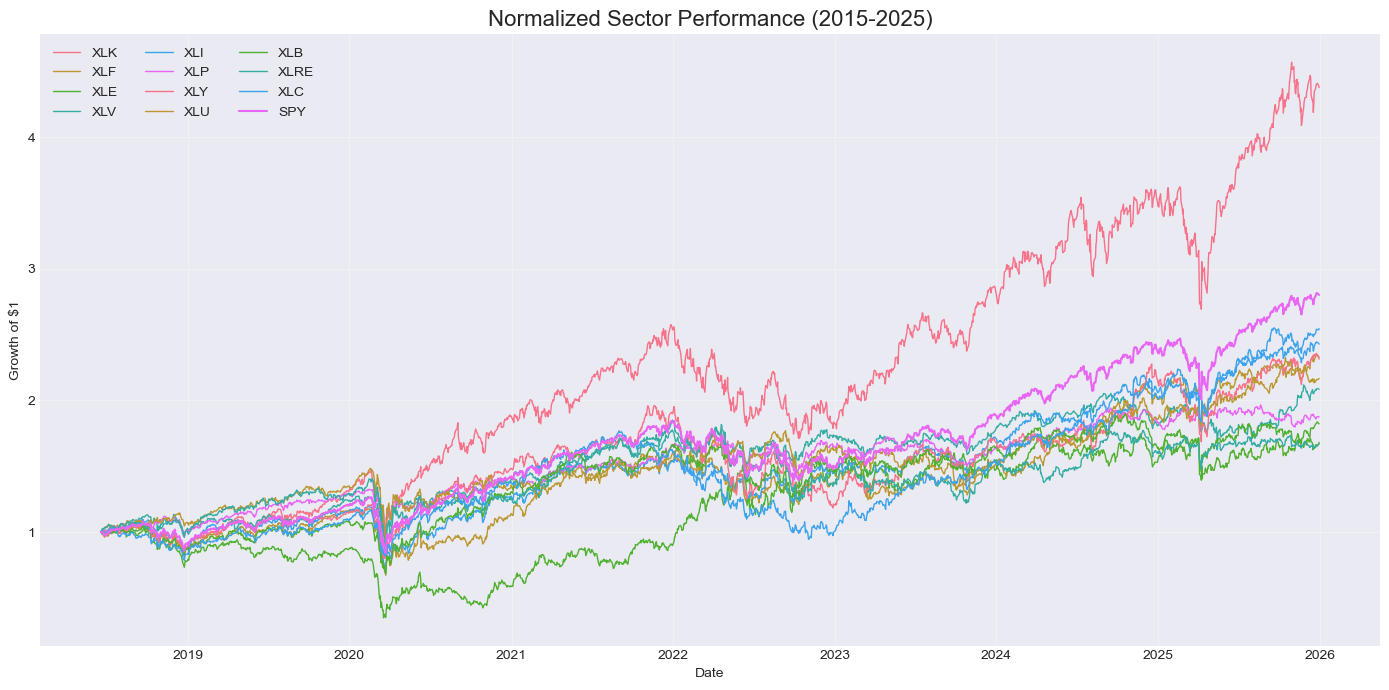

In [9]:
# Plot normalized prices (all start at 1.0)
normalized = data / data.iloc[0]

plt.figure(figsize=(14, 7))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col, linewidth=1.5 if col == 'SPY' else 1)

plt.title('Normalized Sector Performance (2015-2025)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend(loc='upper left', ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

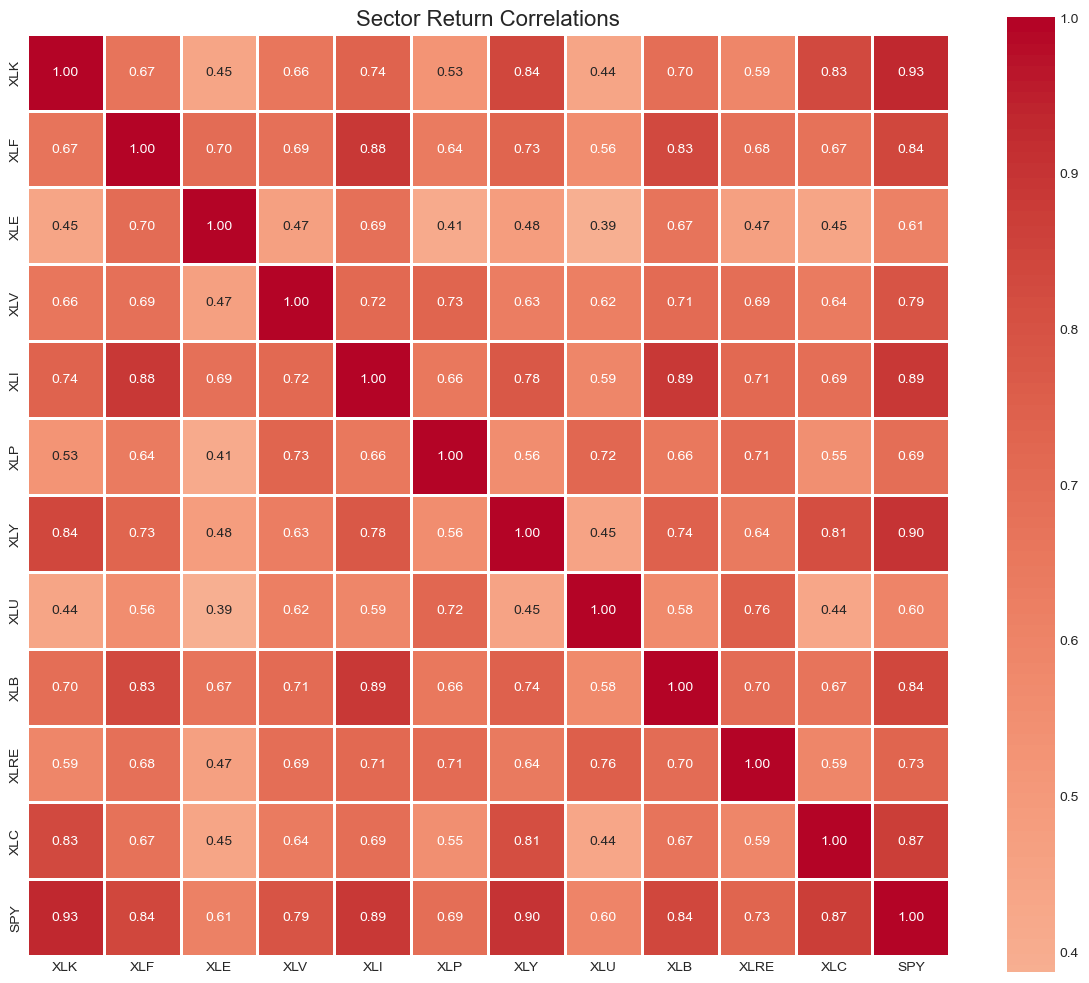


📊 Average correlation with SPY:
SPY     1.000000
XLK     0.933329
XLY     0.900196
XLI     0.886475
XLC     0.869584
XLF     0.844040
XLB     0.842858
XLV     0.790840
XLRE    0.732124
XLP     0.690575
XLE     0.610127
XLU     0.595903
Name: SPY, dtype: float64


In [10]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = returns.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Sector Return Correlations', fontsize=16)
plt.tight_layout()
plt.show()

print("\n📊 Average correlation with SPY:")
print(corr['SPY'].sort_values(ascending=False))

---
## Week 2: Strategy Logic & Backtesting

**Strategy Rules**:
1. **Monthly rebalancing**: Last trading day of each month
2. **Filter**: Only sectors above 200-day SMA
3. **Rank**: By 6-month momentum
4. **Allocate**: Top 3 sectors = 30% each, Cash = 10%
5. **Transaction costs**: 0.1% per trade

**TODO**: Code the strategy below

In [11]:
# Helper: Get last trading day of each month
monthly_dates = data.resample('M').last().index
print(f"Number of rebalancing dates: {len(monthly_dates)}")
print(f"First 5 rebalancing dates: {monthly_dates[:5].tolist()}")

Number of rebalancing dates: 91
First 5 rebalancing dates: [Timestamp('2018-06-30 00:00:00'), Timestamp('2018-07-31 00:00:00'), Timestamp('2018-08-31 00:00:00'), Timestamp('2018-09-30 00:00:00'), Timestamp('2018-10-31 00:00:00')]


In [13]:
# TODO (Student): Implement strategy logic here
# 
# Pseudocode:
# for each month:
#     1. Filter sectors above 200-day SMA
#     2. Rank by 6-month momentum
#     3. Select top 3 sectors
#     4. Allocate 30% each (90% total) + 10% cash
#     5. Calculate returns
#     6. Apply transaction costs

print("Strategy implementation: Student work here")

Strategy implementation: Student work here


In [14]:
# Placeholder: Buy-and-hold SPY for comparison
spy_returns = returns['SPY'].fillna(0)
spy_cumulative = (1 + spy_returns).cumprod()

print(f"SPY final value: ${spy_cumulative.iloc[-1]:.2f}")
print(f"SPY CAGR: {(spy_cumulative.iloc[-1] ** (252 / len(spy_returns)) - 1) * 100:.2f}%")

SPY final value: $2.80
SPY CAGR: 14.69%


---
## Week 3: Performance Analysis

**TODO**: Calculate metrics and create visualizations

In [16]:
# TODO (Student): Calculate performance metrics
# 
# Metrics to calculate:
# - CAGR (Compound Annual Growth Rate)
# - Sharpe Ratio
# - Max Drawdown
# - Volatility
# - Win Rate
# - Turnover

print("Performance analysis: Student work here")

Performance analysis: Student work here


In [17]:
# Placeholder: Performance comparison table template
performance = pd.DataFrame({
    'Metric': ['CAGR', 'Sharpe Ratio', 'Max Drawdown', 'Volatility', 'Win Rate'],
    'Sector Rotation': ['TBD', 'TBD', 'TBD', 'TBD', 'TBD'],
    'SPY Benchmark': ['TBD', 'TBD', 'TBD', 'TBD', 'TBD'],
    'Difference': ['TBD', 'TBD', 'TBD', 'TBD', 'TBD']
})

print("\nPerformance Table (Template):")
performance


Performance Table (Template):


,Metric,Sector Rotation,SPY Benchmark,Difference
0,CAGR,TBD,TBD,TBD
1,Sharpe Ratio,TBD,TBD,TBD
2,Max Drawdown,TBD,TBD,TBD
3,Volatility,TBD,TBD,TBD
4,Win Rate,TBD,TBD,TBD


In [19]:
# TODO (Student): Growth of $10,000 chart
# 
# Create chart showing:
# - Strategy cumulative returns
# - SPY cumulative returns
# - Highlight drawdown periods

print("Growth chart: Student work here")

Growth chart: Student work here


In [20]:
# TODO (Student): Sector allocation heatmap
# 
# Create heatmap showing:
# - X-axis: Time (months)
# - Y-axis: Sectors
# - Color: Allocation percentage
# Shows which sectors were selected each month

print("Allocation heatmap: Student work here")

Allocation heatmap: Student work here


---
## Conclusions & Next Steps

**TODO**: Write your analysis here

### Key Findings
- [Finding 1]
- [Finding 2]
- [Finding 3]

### When Strategy Works Best
- [Period/condition 1]
- [Period/condition 2]

### Limitations
- [Limitation 1]
- [Limitation 2]

### Potential Improvements
- [Improvement 1]
- [Improvement 2]

---

**Project completed by**: [Your Name]

**Date**: [Completion Date]